# EDA: поиск услуг Авито

Что здесь важно для поиска:

- Новые объявления: **90,41%** ID benchmark не встречаются в train.
- Жёсткое равенство `location_id`: пустой пул для **427 / 2 452** запросов benchmark; верхняя граница локального macro Recall@50 на известных train-позитивах — **0,8040**.
- Коды локаций могут иметь разный уровень геоиерархии. Несовпадение ID ещё не доказывает другой физический город.
- **−1** в цене: **8,06%** объявлений benchmark. Это отдельное состояние неизвестного смысла; `log1p(-1)` недопустим.
- Категория **0**: **9,05%** запросов benchmark против **0,0068%** строк train. Не применять жёсткий фильтр равенства.
- Параметры объявления достигают **19 068 символов**: они могут вытеснить описание из лимита энкодера.


In [2]:
import base64
import hashlib
import html
import io
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import HTML, display

ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists()),
    Path.cwd(),
)
QUERY = [
    "search_query",
    "search_location_id",
    "search_is_delivery_search",
    "search_infm_params_text",
    "search_category",
]
TEXT = ["item_title_raw", "item_infm_params_text", "item_description_raw"]
SEED = 42


In [3]:
INPUT_DIR = ROOT / "data/input"

In [4]:
# Общие функции вывода. Весь анализ ниже; дополнительных файлов кода не нужно.
def normalize(column: str) -> pl.Expr:
    """Регистр, ё/е и пробелы; без морфологии и удаления пунктуации."""
    return (
        pl.col(column)
        .fill_null("")
        .str.to_lowercase()
        .str.replace_all("ё", "е")
        .str.replace_all(r"\s+", " ")
        .str.strip_chars()
    )


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def fmt(value) -> str:
    if value is None:
        return "—"
    if isinstance(value, float):
        return f"{value:,.2f}".replace(",", " ")
    if isinstance(value, int):
        return f"{value:,}".replace(",", " ")
    return str(value)


def percent(n, total) -> str:
    return f"{100 * n / total:.2f}%" if total else "нет наблюдений"


class Report:
    """Таблицы и изображения живут в памяти и сохраняются в выводах Jupyter."""

    def __init__(self):
        self.body = []
        self.tables = {}
        self.figures = {}

    def section(self, title: str):
        self.body.append(f"<h2>{html.escape(title)}</h2>")

    def paragraph(self, text: str):
        self.body.append(f"<p>{html.escape(text)}</p>")

    def table(self, name: str, frame: pl.DataFrame, limit: int = 25):
        self.tables[name] = frame
        header = "".join(f"<th>{html.escape(c)}</th>" for c in frame.columns)
        rows = "".join(
            "<tr>" + "".join(f"<td>{html.escape(fmt(v))}</td>" for v in row) + "</tr>"
            for row in frame.head(limit).rows()
        )
        self.body.append(
            '<div style="overflow-x:auto"><table><thead><tr>'
            + header
            + "</tr></thead><tbody>"
            + rows
            + "</tbody></table></div>"
        )
        if frame.height > limit:
            self.body.append(
                f"<p>Показано {limit} из {frame.height} строк. Полная таблица: report.tables['{name}'].</p>"
            )

    def figure(self, name: str, figure, caption: str):
        buffer = io.BytesIO()
        figure.tight_layout()
        figure.savefig(
            buffer, format="png", dpi=145, metadata={"Software": "Avito EDA"}
        )
        plt.close(figure)
        self.figures[name] = buffer.getvalue()
        encoded = base64.b64encode(buffer.getvalue()).decode("ascii")
        self.body.append(
            f'<figure style="margin:24px 0"><img style="max-width:100%" '
            f'src="data:image/png;base64,{encoded}" alt="{html.escape(caption)}">'
            f"<figcaption>{html.escape(caption)}</figcaption></figure>"
        )


def distribution(frame: pl.DataFrame, column: str, name: str) -> pl.DataFrame:
    return (
        frame.group_by(column)
        .len()
        .rename({"len": "count"})
        .with_columns(
            pl.lit(name).alias("dataset"),
            (100 * pl.col("count") / frame.height).alias("percent"),
        )
        .sort(["count", column], descending=[True, False])
    )


def quantiles(frame: pl.DataFrame, column: str, name: str) -> dict:
    values = frame[column].cast(pl.Float64).drop_nulls()
    return {
        "dataset": name,
        "field": column,
        "non_null": len(values),
        "min": values.min(),
        **{
            f"p{int(q * 100):02}": values.quantile(q, interpolation="linear")
            for q in [0.01, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
        },
        "max": values.max(),
    }


def bar_compare(
    report: Report, name: str, labels: list[str], series: dict, title: str, caption: str
):
    figure, ax = plt.subplots(figsize=(10, 4.5))
    x = np.arange(len(labels))
    width = 0.8 / len(series)
    for i, (label, values) in enumerate(series.items()):
        bars = ax.bar(
            x + (i - (len(series) - 1) / 2) * width, values, width, label=label
        )
        ax.bar_label(
            bars,
            labels=["<0.1" if 0 < v < 0.1 else f"{v:.1f}" for v in values],
            fontsize=8,
            padding=3,
        )
    ax.set_xticks(x, labels)
    ax.set_ylabel("Доля, %")
    ax.set_ylim(0, max(10, max(max(v) for v in series.values()) * 1.23))
    ax.set_title(title)
    ax.legend(fontsize=9)
    report.figure(name, figure, caption)


In [5]:
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.alpha": 0.18,
    }
)
paths = {
    key: INPUT_DIR / f"{key}.parquet"
    for key in ["train", "benchmark_queries", "benchmark_items"]
}
print("Чтение трёх Parquet…", flush=True)
train, queries, items = [pl.read_parquet(paths[key]) for key in paths]
item_columns = [c for c in train.columns if c.startswith("item_")]
train_items = train.select(item_columns).unique(
    "item_id", keep="first", maintain_order=True
)
contexts = train.select(QUERY).unique(maintain_order=True)
pair_columns = QUERY + ["item_id"]
pairs = train.unique(pair_columns, keep="first", maintain_order=True)
raw_texts = train.select("search_query").unique(maintain_order=True)
norm_train = raw_texts.select(normalize("search_query").alias("normalized")).unique()
norm_queries = queries.with_columns(normalize("search_query").alias("normalized"))
report = Report()
metrics = {}


Чтение трёх Parquet…


In [6]:
report.section("2. Размеры, схема и целостность")
_output_start = len(report.body)
sizes = pl.DataFrame(
    [
        {"Единица": "Положительные строки train", "Количество": train.height},
        {
            "Единица": "Уникальные пары: полный запрос + item_id",
            "Количество": pairs.height,
        },
        {"Единица": "Полные контексты train", "Количество": contexts.height},
        {"Единица": "Уникальные исходные тексты train", "Количество": raw_texts.height},
        {"Единица": "Нормализованные тексты train", "Количество": norm_train.height},
        {"Единица": "Уникальные объявления train", "Количество": train_items.height},
        {"Единица": "Запросы benchmark", "Количество": queries.height},
        {"Единица": "Объявления benchmark", "Количество": items.height},
    ]
)
report.table("sizes", sizes)
metrics["sizes"] = dict(sizes.iter_rows())
schema_rows, integrity = [], []
for name, frame in [
    ("train", train),
    ("benchmark_queries", queries),
    ("benchmark_items", items),
]:
    for column, dtype in frame.schema.items():
        schema_rows.append(
            {
                "dataset": name,
                "column": column,
                "dtype": str(dtype),
                "nulls": frame[column].null_count(),
            }
        )
    id_col = "query_id" if name == "benchmark_queries" else "item_id"
    pattern = r"^[0-9A-Za-z]{16}$" if id_col == "query_id" else r"^[0-9a-f]{16}$"
    integrity.append(
        {
            "dataset": name,
            "rows": frame.height,
            "duplicate_full_rows": frame.height - frame.n_unique(),
            "null_ids": frame[id_col].null_count(),
            "invalid_non_null_ids": frame.filter(
                pl.col(id_col).is_not_null() & ~pl.col(id_col).str.contains(pattern)
            ).height,
            "unique_ids": frame[id_col].n_unique(),
        }
    )
report.table("integrity", pl.DataFrame(integrity))
report.table("schema", pl.DataFrame(schema_rows), limit=8)
extra_pairs = train.height - pairs.height
report.paragraph(
    f"Повторные пары с тем же полным запросом и item_id: {fmt(extra_pairs)} ({percent(extra_pairs, train.height)} строк)"
)
variation = train.group_by("item_id").agg(
    [pl.col(c).n_unique().alias(c) for c in item_columns if c != "item_id"]
)
variation_counts = {
    c: variation.filter(pl.col(c) > 1).height for c in item_columns if c != "item_id"
}
report.table(
    "item_conflicts",
    pl.DataFrame(
        {
            "field": list(variation_counts),
            "conflicting_item_ids": list(variation_counts.values()),
        }
    ),
)
report.paragraph(
    "Таблица конфликтов проверяет все 13 атрибутов одного item_id внутри train (null считается отдельным значением). В остальных item-агрегатах используется первое в порядке файла представление ID; при ненулевых конфликтах выбор версии нужно пересмотреть до индексации."
)

display(HTML("".join(report.body[_output_start:])))

**Вывод.** Данные технически чистые: ID без пропусков и ошибок формата, у одного `item_id` все 13 атрибутов одинаковы во всех строках train. Особенность одна — 30 619 повторов пары «полный запрос + `item_id`» (6,15% строк); скорее это повторные выборы, чем ошибка. Для метрики позитивы запроса собираются в множество, повтор не считается дважды.

Строка train не равна запросу: 497 673 строки дают 354 463 разных контекста и всего 74 529 разных текстов.

## 3. Новые запросы и новые объявления

Сравнение,Есть в train,Всего benchmark,"Доля, %"
Текст запроса без нормализации,907,2 452,36.99
"Текст: регистр, ё/е, пробелы",916,2 452,37.36
Полный контекст запроса,108,2 452,4.40
ID объявления,18 142,189 212,9.59

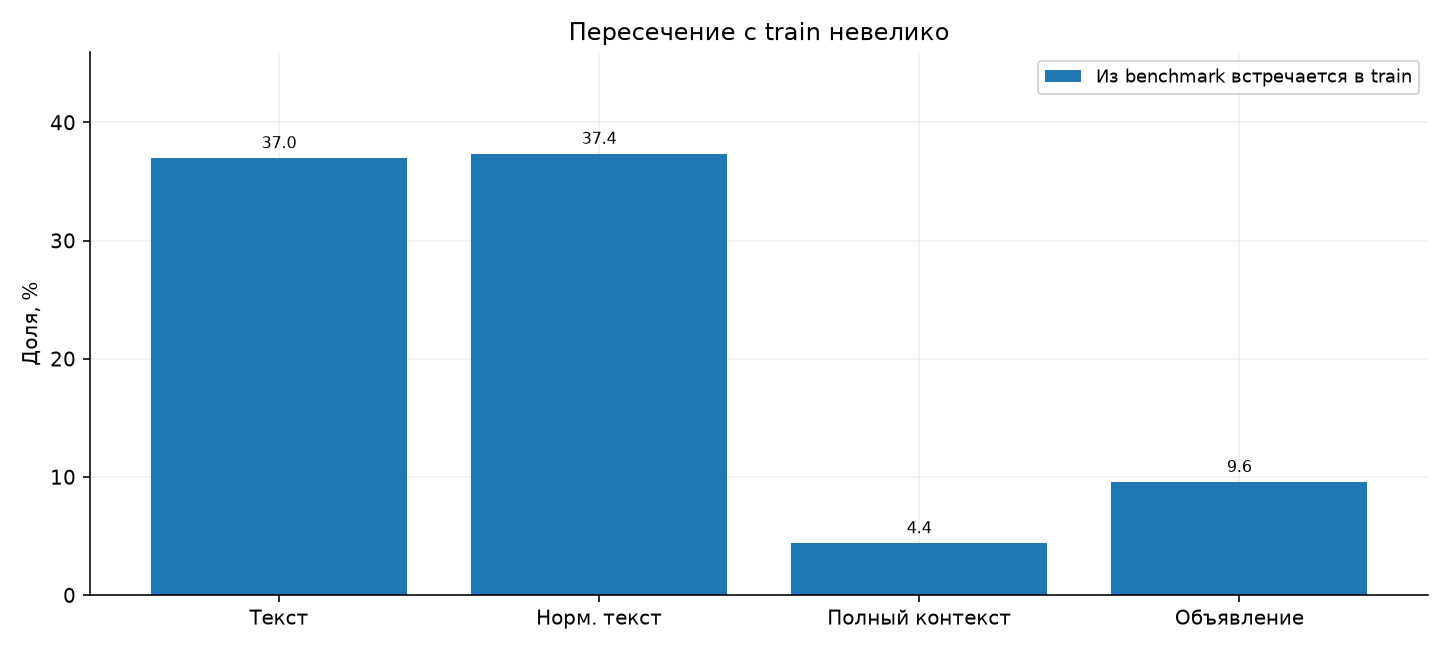

In [7]:
report.section("3. Новые запросы и новые объявления")
_output_start = len(report.body)
raw_seen = queries.join(raw_texts, on="search_query", how="semi").height
norm_seen = norm_queries.join(norm_train, on="normalized", how="semi").height
context_seen = queries.join(contexts, on=QUERY, how="semi", nulls_equal=True).height
item_seen = items.join(train_items.select("item_id"), on="item_id", how="semi").height
overlap = pl.DataFrame(
    [
        {
            "Сравнение": "Текст запроса без нормализации",
            "Есть в train": raw_seen,
            "Всего benchmark": queries.height,
        },
        {
            "Сравнение": "Текст: регистр, ё/е, пробелы",
            "Есть в train": norm_seen,
            "Всего benchmark": queries.height,
        },
        {
            "Сравнение": "Полный контекст запроса",
            "Есть в train": context_seen,
            "Всего benchmark": queries.height,
        },
        {
            "Сравнение": "ID объявления",
            "Есть в train": item_seen,
            "Всего benchmark": items.height,
        },
    ]
).with_columns(
    (100 * pl.col("Есть в train") / pl.col("Всего benchmark")).alias("Доля, %")
)
report.table("overlap", overlap)
metrics["overlap"] = overlap.to_dicts()
bar_compare(
    report,
    "overlap",
    ["Текст", "Норм. текст", "Полный контекст", "Объявление"],
    {"Из benchmark встречается в train": overlap["Доля, %"].to_list()},
    "Пересечение с train невелико",
    "Знаменатель: все запросы benchmark для первых трёх столбцов; все объявления benchmark для четвёртого.",
)
normalized_duplicates = norm_queries.height - norm_queries["normalized"].n_unique()
report.paragraph(
    f"{percent(items.height - item_seen, items.height)} объявлений benchmark не имеют взаимодействий в train; {percent(queries.height - raw_seen, queries.height)} текстов запросов тоже новые. После нормализации в benchmark объединяются {normalized_duplicates} строк. Нужен поиск по содержанию и split по нормализованному тексту, а не случайным строкам. Новые ID не гарантируют новый текст: проверяем дубли содержания отдельно ниже."
)

display(HTML("".join(report.body[_output_start:])))

**Вывод.** Запомнить ответы из train не получится: 90,41% объявлений benchmark в train не встречались, 63% текстов запросов новые, полностью совпадающий контекст — только у 4,4% запросов. Искать нужно по содержанию объявления, а не по истории его выборов.

Отсюда же правило валидации: train делится по нормализованным текстам, чтобы запросы dev были для модели такими же новыми, как на benchmark.

## 4. Сдвиг фильтров, категории и доставки


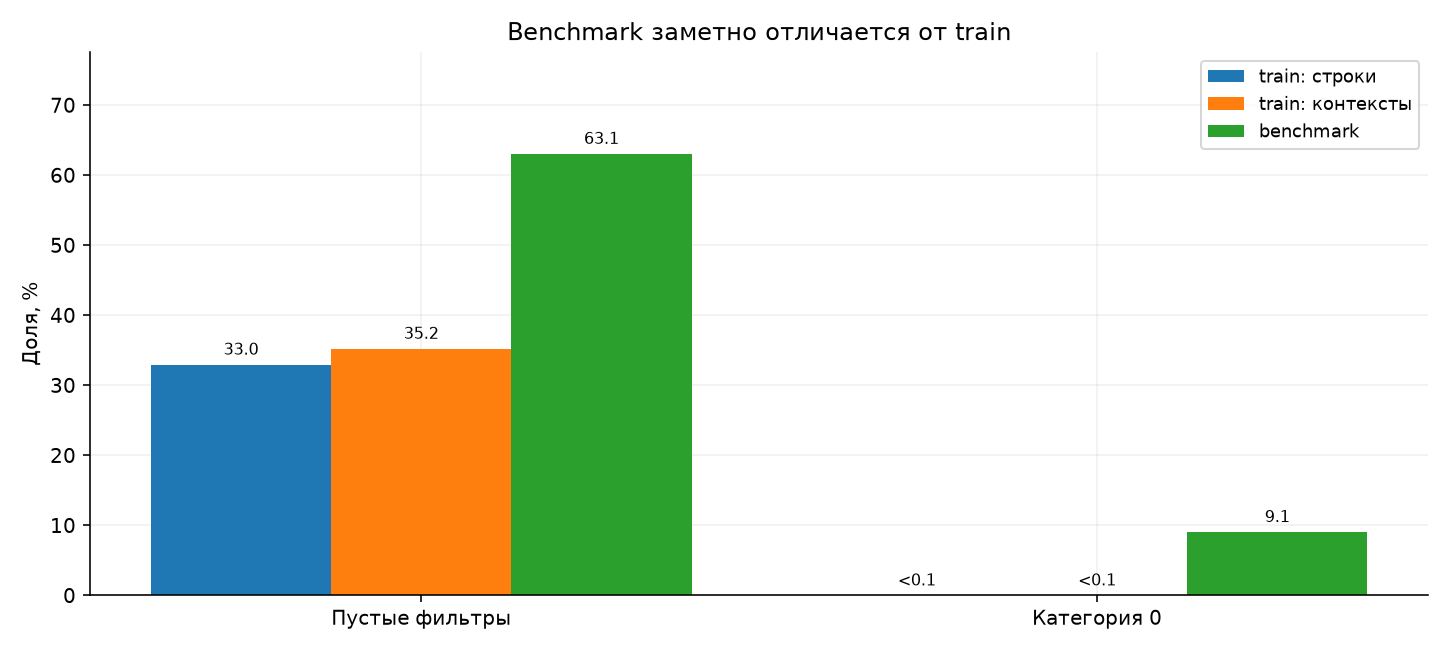

In [8]:
report.section("4. Сдвиг фильтров, категории и доставки")
_output_start = len(report.body)
query_frames = {
    "train: строки": train,
    "train: контексты": contexts,
    "benchmark": queries,
}
shift = []
for name, frame in query_frames.items():
    shift.append(
        {
            "dataset": name,
            "n": frame.height,
            "empty_filters_pct": 100
            * frame.select(
                (
                    pl.col("search_infm_params_text").fill_null("").str.strip_chars()
                    == ""
                ).mean()
            ).item(),
            "category_0_pct": 100
            * frame.select((pl.col("search_category") == 0).mean()).item(),
            "delivery_1_count": frame.filter(
                pl.col("search_is_delivery_search") == 1
            ).height,
        }
    )
shift_frame = pl.DataFrame(shift)
report.table("query_shift", shift_frame)
metrics["query_shift"] = shift
bar_compare(
    report,
    "query_shift",
    ["Пустые фильтры", "Категория 0"],
    {r["dataset"]: [r["empty_filters_pct"], r["category_0_pct"]] for r in shift},
    "Benchmark заметно отличается от train",
    "Контексты train дедуплицированы по всем пяти search_* полям. Это всё ещё не распределение уникальных текстов benchmark.",
)
report.table(
    "search_categories",
    pl.concat([distribution(f, "search_category", n) for n, f in query_frames.items()]),
)
report.table(
    "top_filters",
    pl.concat(
        [
            distribution(f, "search_infm_params_text", n).head(10)
            for n, f in query_frames.items()
        ]
    ),
    limit=30,
)
report.paragraph(
    "Категория 0 означает неизвестное нам состояние: в схеме нет расшифровки. Нельзя считать её обычной категорией и отбрасывать все несовпадения. Пустой фильтр также не равен нерелевантности. Доставка почти отсутствует — эффект этого признака на такой выборке надёжно оценить нельзя. Полезные отдельные срезы: категория 0, пустые фильтры, новые тексты."
)

display(HTML("".join(report.body[_output_start:])))

**Вывод.** Benchmark не похож на train по контексту запроса. Без фильтров: 33% строк train против 63% запросов benchmark. Категория `0`: 34 строки train против 9% benchmark. Модель, привыкшая опираться на фильтры и категорию, на benchmark часто останется без них.

Поэтому категорию не фильтруем, пустые фильтры и категорию `0` передаём признаками и смотрим качество на этих срезах отдельно. Доставка (12 строк train, 0 в benchmark) для поиска бесполезна.

## 5. География: цена жёсткой фильтрации


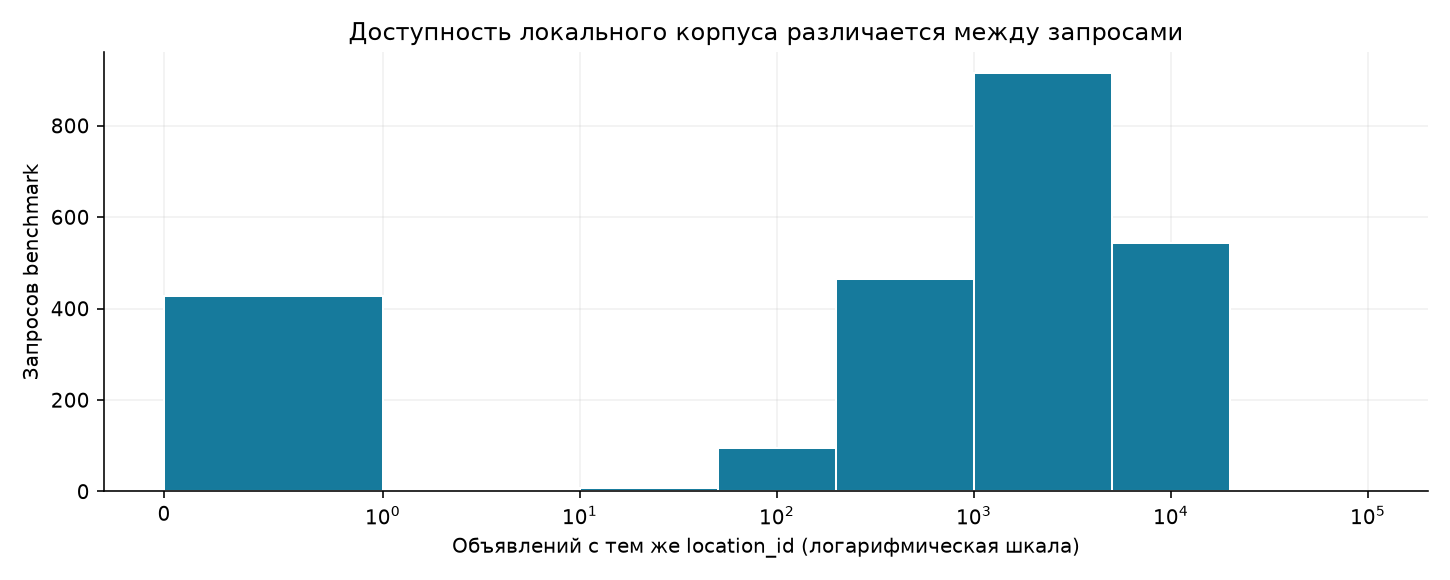

In [9]:
report.section("5. География: цена жёсткой фильтрации")
_output_start = len(report.body)
match = []
for name, frame in [("строки train", train), ("уникальные пары", pairs)]:
    match.append(
        {
            "Единица": name,
            "n": frame.height,
            "location_match_pct": 100
            * frame.select(
                (pl.col("search_location_id") == pl.col("item_location_id"))
                .fill_null(False)
                .mean()
            ).item(),
            "category_match_pct": 100
            * frame.select(
                (pl.col("search_category") == pl.col("item_category_id"))
                .fill_null(False)
                .mean()
            ).item(),
        }
    )
positive_groups = (
    pairs.group_by(QUERY)
    .agg(
        pl.len().alias("positives"),
        (pl.col("search_location_id") == pl.col("item_location_id"))
        .fill_null(False)
        .sum()
        .alias("local_positives"),
        (pl.col("search_category") == pl.col("item_category_id"))
        .fill_null(False)
        .sum()
        .alias("category_positives"),
    )
    .sort(QUERY)
)
local_ceiling = positive_groups.select(
    (pl.min_horizontal("local_positives", pl.lit(50)) / pl.col("positives")).mean()
).item()
ideal_ceiling = positive_groups.select(
    (pl.min_horizontal("positives", pl.lit(50)) / pl.col("positives")).mean()
).item()
category_ceiling = positive_groups.select(
    (pl.min_horizontal("category_positives", pl.lit(50)) / pl.col("positives")).mean()
).item()
report.table("positive_matches", pl.DataFrame(match))
metrics["oracle_recall50"] = {
    "unfiltered": ideal_ceiling,
    "same_location_only": local_ceiling,
    "same_category_only": category_ceiling,
}
report.paragraph(
    f"Даже идеальный отбор после жёсткого совпадения location_id ограничен macro Recall@50 = {local_ceiling:.4f}; без этого ограничения верхняя граница {ideal_ceiling:.4f}. Расчёт по всем {fmt(positive_groups.height)} полным контекстам train: среднее min(50, число допустимых позитивов) / число всех уникальных позитивов. Это теоретическая граница на обучающих метках, не результат модели и не прогноз платформы. Для точной категории аналогичная граница {category_ceiling:.4f}."
)
local_sizes = (
    items.group_by("item_location_id")
    .len()
    .rename({"item_location_id": "search_location_id", "len": "local_items"})
)
category_sizes = (
    items.group_by("item_category_id")
    .len()
    .rename({"item_category_id": "search_category", "len": "category_items"})
)
supply = (
    queries.join(local_sizes, on="search_location_id", how="left")
    .join(category_sizes, on="search_category", how="left")
    .with_columns(pl.col("local_items", "category_items").fill_null(0))
)
report.tables["benchmark_candidate_supply"] = supply.select(
    "query_id", "search_location_id", "search_category", "local_items", "category_items"
)
report.table(
    "candidate_supply_summary",
    pl.DataFrame(
        [
            {
                "Ограничение": field,
                "Запросов без кандидатов": supply.filter(pl.col(field) == 0).height,
                "Запросов с <50 кандидатами": supply.filter(pl.col(field) < 50).height,
                "Медиана кандидатов": supply[field].median(),
                "Минимум": supply[field].min(),
                "Максимум": supply[field].max(),
            }
            for field in ["local_items", "category_items"]
        ]
    ),
)
report.table(
    "locations_without_items",
    supply.filter(pl.col("local_items") == 0)
    .group_by("search_location_id")
    .len()
    .sort(["len", "search_location_id"], descending=[True, False]),
    limit=10,
)
no_local = supply.filter(pl.col("local_items") == 0).height
report.paragraph(
    f"У {no_local} из {queries.height} запросов benchmark ({percent(no_local, queries.height)}) нет ни одного объявления с тем же location_id. Равенство кодов даёт пустой локальный пул. Неизвестно, являются ли эти коды городами, регионами или уровнями геоиерархии. Поэтому несовпадение ID нельзя автоматически трактовать как другой физический город. Без справочника географии не восстанавливаем родительские регионы по числам."
)
figure, ax = plt.subplots(figsize=(10, 4))
ax.hist(
    supply["local_items"].to_numpy(),
    bins=np.r_[0, 1, 10, 50, 200, 1000, 5000, 20000, 100000],
    color="#167a9c",
    edgecolor="white",
)
ax.set_xscale("symlog", linthresh=1)
ax.set_xlabel("Объявлений с тем же location_id (логарифмическая шкала)")
ax.set_ylabel("Запросов benchmark")
ax.set_title("Доступность локального корпуса различается между запросами")
report.figure(
    "local_supply",
    figure,
    "Каждый запрос benchmark учитывается один раз; границы корзин 0, 1, 10, 50, 200, 1000, 5000, 20000, 100000.",
)
report.paragraph(
    "Решение: глобальные кандидаты плюс дополнительные кандидаты с тем же location_id; совпадение — мягкий признак. Несовпадение ID может отражать геоиерархию, выезд, удалённую услугу или маршрут, но данные не позволяют выбрать объяснение. Расстояние до пользователя не вычисляем: его координат нет."
)
location_counts = pl.DataFrame(
    [
        {"dataset": n, "locations": f[c].n_unique()}
        for n, f, c in [
            ("train: контексты", contexts, "search_location_id"),
            ("benchmark: запросы", queries, "search_location_id"),
            ("train: объявления", train_items, "item_location_id"),
            ("benchmark: объявления", items, "item_location_id"),
        ]
    ]
)
report.table("location_counts", location_counts)

display(HTML("".join(report.body[_output_start:])))

**Вывод.** Город — сильный, но не жёсткий сигнал. 83% выбранных объявлений имеют тот же `location_id`, что и запрос, 17% — другой. У 427 из 2 452 запросов benchmark (17,4%) в корпусе нет ни одного объявления с тем же `location_id`, ещё у 8 их меньше 50. Если показывать только «свой город», даже идеальный поиск не превысит Recall@50 = 0,804.

Смысл кодов неизвестен: несовпадение может означать район против города или онлайн-услугу. Решение: искать по всему корпусу, дополнительно брать местные объявления, совпадение города отдать модели как признак.

## 6. Длина запросов, популярность и неоднозначность

Анализ объявлений и текстовых признаков…



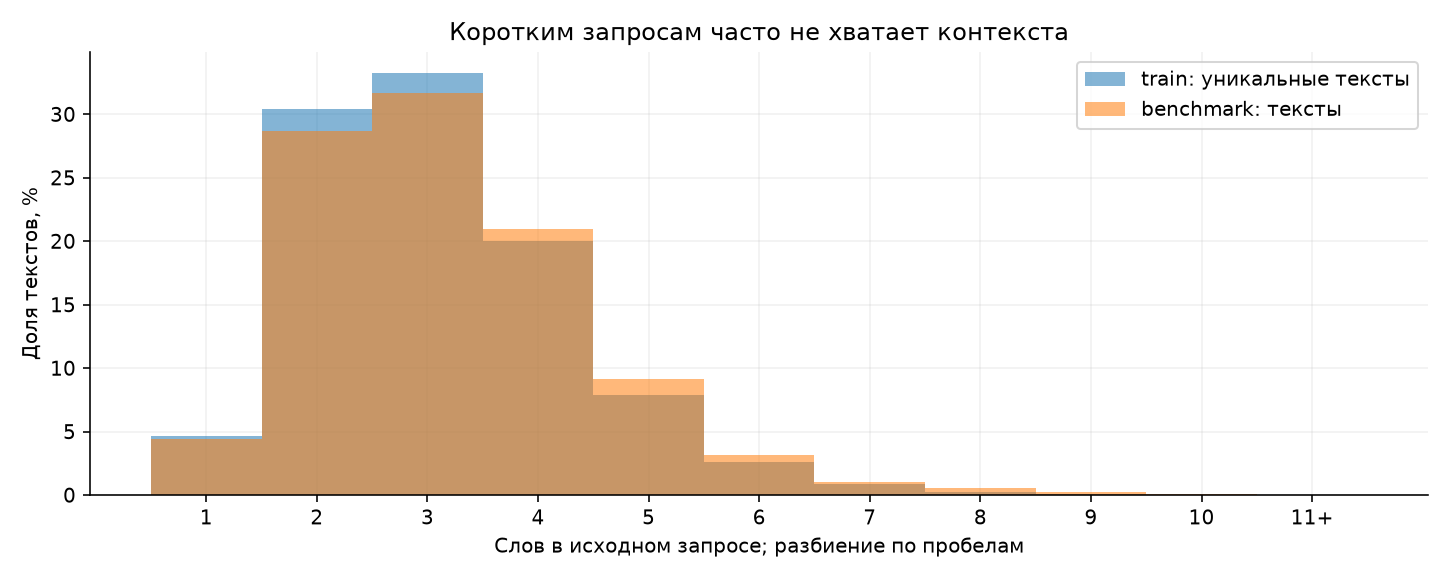
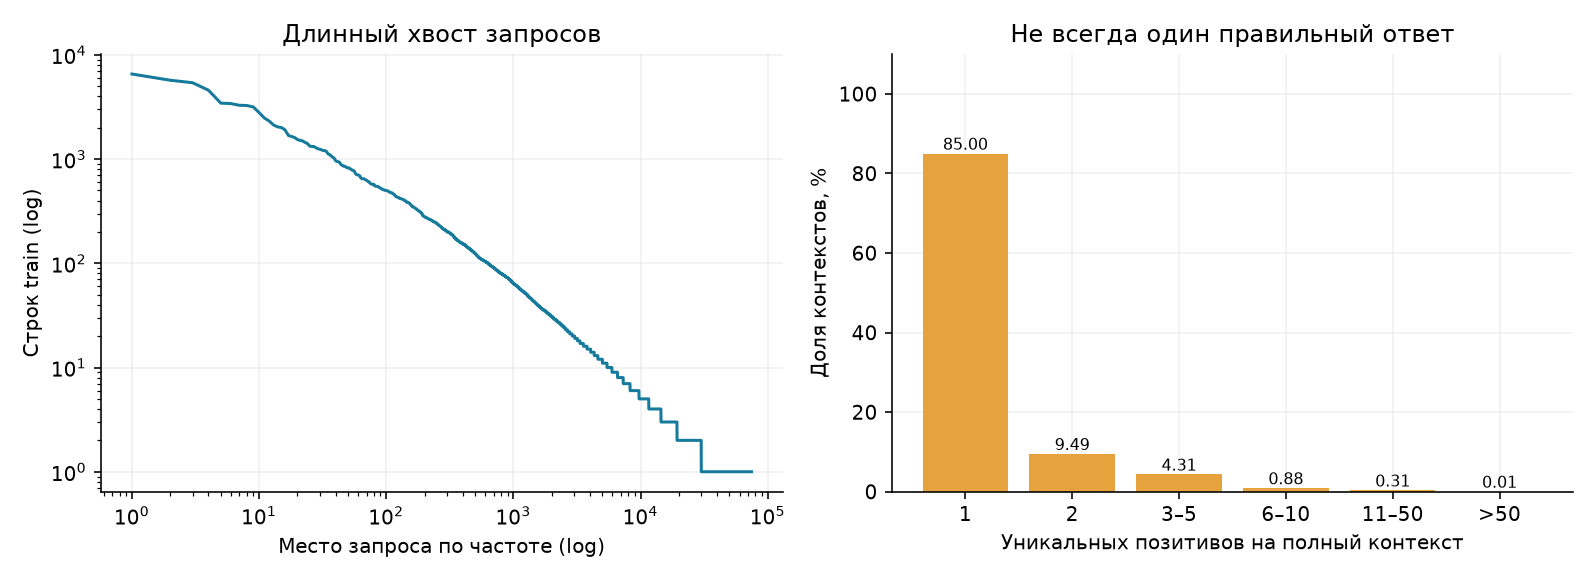

In [10]:
report.section("6. Длина запросов, популярность и неоднозначность")
_output_start = len(report.body)
text_frames = {
    "train: уникальные тексты": raw_texts,
    "benchmark: тексты": queries.select("search_query"),
}
word_counts = {}
for name, frame in text_frames.items():
    word_counts[name] = frame.select(
        pl.col("search_query").fill_null("").str.count_matches(r"\S+").alias("words")
    )
report.table(
    "query_length_quantiles",
    pl.DataFrame([quantiles(f, "words", n) for n, f in word_counts.items()]),
)
figure, ax = plt.subplots(figsize=(10, 4))
for name, frame in word_counts.items():
    values = frame["words"].to_numpy()
    ax.hist(
        np.minimum(values, 11),
        bins=np.arange(0.5, 12.5),
        weights=np.ones(len(values)) * 100 / len(values),
        alpha=0.55,
        label=name,
    )
ax.set_xticks(range(1, 12), [*map(str, range(1, 11)), "11+"])
ax.set_xlabel("Слов в исходном запросе; разбиение по пробелам")
ax.set_ylabel("Доля текстов, %")
ax.set_title("Коротким запросам часто не хватает контекста")
ax.legend()
report.figure(
    "query_words",
    figure,
    "Равный вес у каждого уникального исходного текста; длинный хвост объединён в 11+ слов.",
)
popularity = (
    train.group_by("search_query")
    .agg(
        pl.len().alias("rows"),
        pl.col("item_id").n_unique().alias("items"),
        pl.col("search_location_id").n_unique().alias("locations"),
    )
    .sort(["rows", "search_query"], descending=[True, False])
)
report.table("popular_queries", popularity.head(20))
multigeo = popularity.filter(pl.col("locations") > 1).height
top100 = popularity.head(100)["rows"].sum()
report.paragraph(
    f"100 самых частых текстов дают {percent(top100, train.height)} строк train. {fmt(multigeo)} из {fmt(popularity.height)} текстов встречаются в нескольких location_id. Нельзя объединять позитивы только по тексту: исполнитель для одного города не становится позитивом для другого. При этом split должен держать все версии одного нормализованного текста вместе, чтобы не переоценить обобщение."
)
figure, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(
    np.arange(1, popularity.height + 1), popularity["rows"].to_numpy(), color="#167a9c"
)
axes[0].set(
    xscale="log",
    yscale="log",
    xlabel="Место запроса по частоте (log)",
    ylabel="Строк train (log)",
    title="Длинный хвост запросов",
)
counts = positive_groups["positives"].to_numpy()
labels = ["1", "2", "3–5", "6–10", "11–50", ">50"]
amounts = [
    sum(counts == 1),
    sum(counts == 2),
    sum((counts >= 3) & (counts <= 5)),
    sum((counts >= 6) & (counts <= 10)),
    sum((counts >= 11) & (counts <= 50)),
    sum(counts > 50),
]
bars = axes[1].bar(labels, 100 * np.array(amounts) / len(counts), color="#e6a23c")
axes[1].bar_label(bars, fmt="%.2f", fontsize=8)
axes[1].set(
    xlabel="Уникальных позитивов на полный контекст",
    ylabel="Доля контекстов, %",
    title="Не всегда один правильный ответ",
    ylim=(0, 110),
)
report.figure(
    "query_tail",
    figure,
    "Слева частота исходного текста по строкам train. Справа положительные item_id после дедупликации пар.",
)
report.table(
    "positive_count_quantiles",
    pl.DataFrame([quantiles(positive_groups, "positives", "train: полные контексты")]),
)
report.table(
    "many_positives",
    positive_groups.sort(
        ["positives", *QUERY], descending=[True, *([False] * len(QUERY))]
    ).head(10),
)
report.paragraph(
    "Recall@50 нужно считать сначала для каждого полного контекста, затем усреднять. При более чем 50 известных позитивах даже идеальный top-50 не достигает Recall=1. Отсутствие item_id среди выбранных не доказывает его нерелевантность: это поведенческая, неполная разметка. При обучении негативы из выдачи будут предполагаемыми."
)

print("Анализ объявлений и текстовых признаков…", flush=True)
display(HTML("".join(report.body[_output_start:])))

**Вывод.** Запросы короткие: медиана 3 слова, у 90% не больше 5. По ним трудно понять точный интент, особенно без фильтров.

Популярность сильно перекошена: 100 самых частых текстов дают 25% строк train («маникюр» — 6 540 строк). Поэтому оценка идёт по уникальным запросам с равным весом, иначе метрику определят несколько популярных формулировок. Один текст в разных городах — разные запросы (27 478 текстов встречаются в нескольких `location_id`), позитивы по тексту не объединяем.

Обычно у контекста одно выбранное объявление (медиана 1, p90 2), но бывает до 278; при >50 позитивах Recall = 1 недостижим в принципе.

## 7. Пропуски, цена, рейтинг и координаты


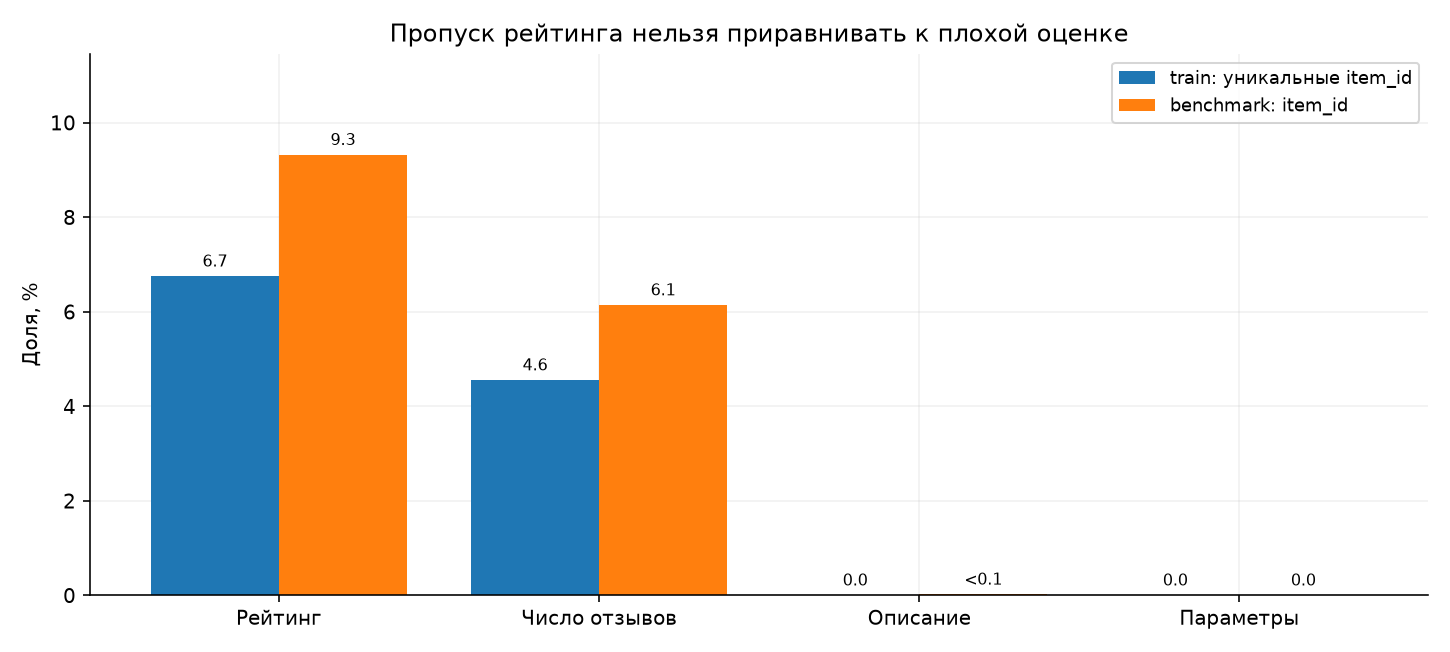
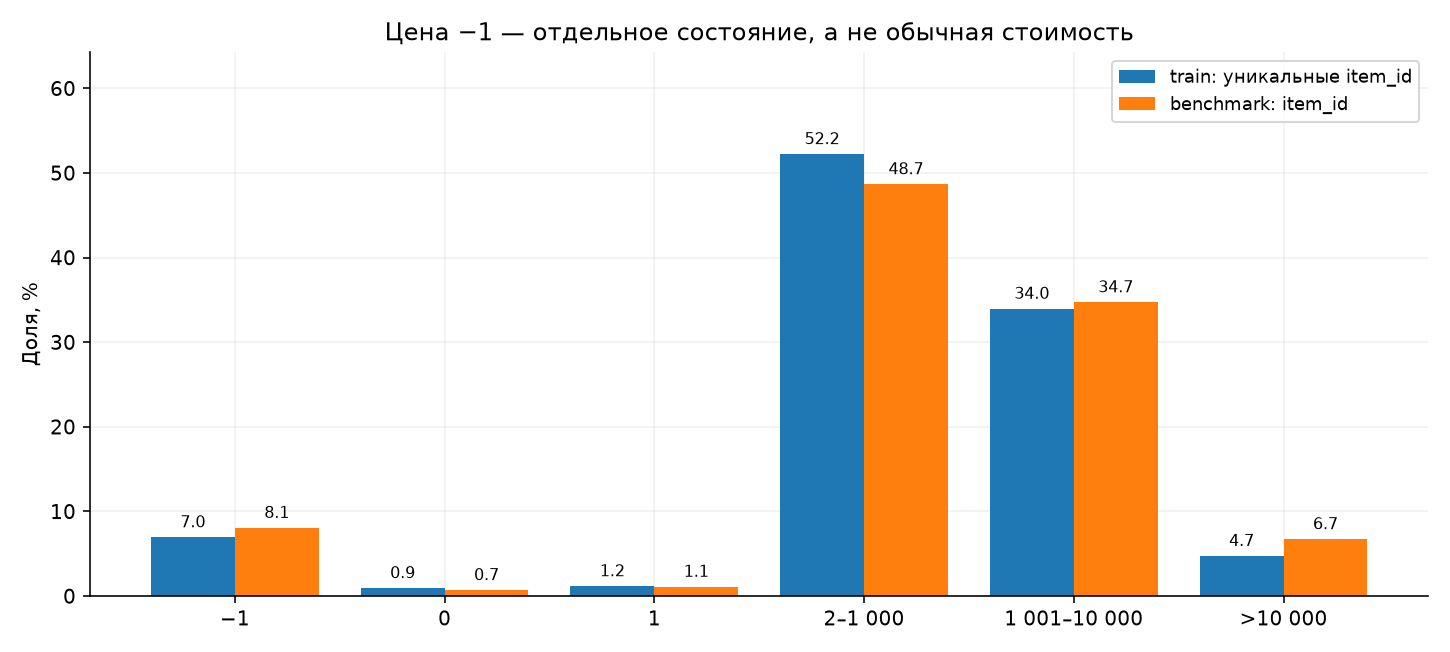
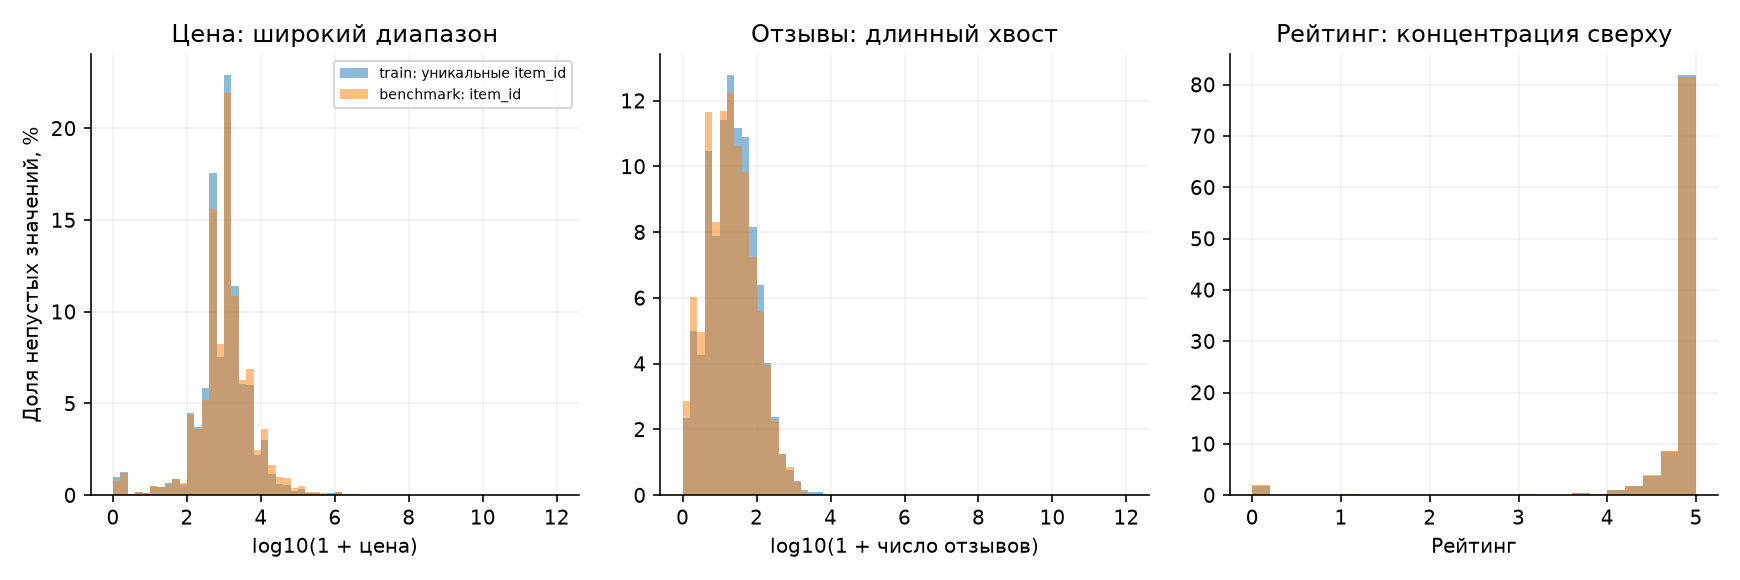

In [11]:
report.section("7. Пропуски, цена, рейтинг и координаты")
_output_start = len(report.body)
item_frames = {"train: уникальные item_id": train_items, "benchmark: item_id": items}
missing = []
for name, frame in item_frames.items():
    for column in item_columns:
        empty = (
            frame.filter(
                pl.col(column).is_not_null() & (pl.col(column).str.strip_chars() == "")
            ).height
            if frame.schema[column] == pl.String
            else 0
        )
        missing.append(
            {
                "dataset": name,
                "field": column,
                "null": frame[column].null_count(),
                "empty_string": empty,
                "missing_pct": 100
                * (frame[column].null_count() + empty)
                / frame.height,
            }
        )
missing_frame = pl.DataFrame(missing)
report.table("item_missingness", missing_frame.filter(pl.col("missing_pct") > 0))
fields = [
    "item_rating",
    "item_rating_reviews_count",
    "item_description_raw",
    "item_infm_params_text",
]
bar_compare(
    report,
    "missingness",
    ["Рейтинг", "Число отзывов", "Описание", "Параметры"],
    {
        n: [
            missing_frame.filter((pl.col("dataset") == n) & (pl.col("field") == c))[
                "missing_pct"
            ].item()
            for c in fields
        ]
        for n in item_frames
    },
    "Пропуск рейтинга нельзя приравнивать к плохой оценке",
    "Доля null или пустых строк среди уникальных объявлений каждого корпуса.",
)
numeric = [
    "item_price",
    "item_rating",
    "item_rating_reviews_count",
    "item_latitude",
    "item_longitude",
]
report.table(
    "numeric_quantiles",
    pl.DataFrame([quantiles(f, c, n) for n, f in item_frames.items() for c in numeric]),
)
anomalies = []
for name, frame in item_frames.items():
    checks = {
        "price_negative": pl.col("item_price") < 0,
        "price_zero": pl.col("item_price") == 0,
        "price_one": pl.col("item_price") == 1,
        "price_over_1_million": pl.col("item_price") > 1_000_000,
        "rating_outside_0_5": ~pl.col("item_rating").is_between(0, 5),
        "reviews_negative": pl.col("item_rating_reviews_count") < 0,
        "reviews_fractional": pl.col("item_rating_reviews_count")
        != pl.col("item_rating_reviews_count").floor(),
        "latitude_outside_90": pl.col("item_latitude").abs() > 90,
        "longitude_outside_180": pl.col("item_longitude").abs() > 180,
        "zero_coordinates": (pl.col("item_latitude") == 0)
        & (pl.col("item_longitude") == 0),
        "both_contacts_disabled": pl.col("item_is_phone_hidden")
        & pl.col("item_is_message_forbidden"),
    }
    for label, condition in checks.items():
        count = frame.filter(condition).height
        anomalies.append(
            {
                "dataset": name,
                "check": label,
                "count": count,
                "percent": 100 * count / frame.height,
            }
        )
report.table("numeric_anomalies", pl.DataFrame(anomalies), limit=30)
report.table(
    "negative_prices",
    pl.concat(
        [
            distribution(f.filter(pl.col("item_price") < 0), "item_price", n)
            for n, f in item_frames.items()
        ]
    ),
)
report.paragraph(
    "Все отрицательные цены в этих файлах равны −1: 23 974 уникальных объявления train (6,95%) и 15 248 benchmark (8,06%). Вероятный служебный маркер неизвестной/договорной цены; его смысл не документирован. Не интерпретировать как стоимость и не подавать в log1p: log1p(−1) даёт −∞. Сохранить отдельный признак price_is_negative; преобразовывать только неотрицательную стоимость, неизвестную заполнять отдельно."
)
price_labels = ["−1", "0", "1", "2–1 000", "1 001–10 000", ">10 000"]
price_series = {}
for name, frame in item_frames.items():
    price = pl.col("item_price")
    price_series[name] = [
        100 * frame.filter(condition).height / frame.height
        for condition in [
            price == -1,
            price == 0,
            price == 1,
            (price > 1) & (price <= 1000),
            (price > 1000) & (price <= 10000),
            price > 10000,
        ]
    ]
bar_compare(
    report,
    "price_buckets",
    price_labels,
    price_series,
    "Цена −1 — отдельное состояние, а не обычная стоимость",
    "Знаменатель — все уникальные объявления корпуса. Неотрицательные цены дополнительно показаны в логарифмическом масштабе ниже.",
)
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
for name, frame in item_frames.items():
    for ax, column in zip(axes[:2], ["item_price", "item_rating_reviews_count"]):
        values = frame[column].cast(pl.Float64).drop_nulls().to_numpy()
        values = values[np.isfinite(values) & (values >= 0)]
        ax.hist(
            np.log10(1 + values),
            bins=np.linspace(0, 12, 61),
            weights=np.ones(len(values)) * 100 / len(values),
            alpha=0.5,
            label=name,
        )
    ratings = frame["item_rating"].drop_nulls().to_numpy()
    axes[2].hist(
        ratings,
        bins=np.linspace(0, 5, 26),
        weights=np.ones(len(ratings)) * 100 / len(ratings),
        alpha=0.5,
        label=name,
    )
axes[0].set(
    xlabel="log10(1 + цена)",
    title="Цена: широкий диапазон",
    ylabel="Доля непустых значений, %",
)
axes[1].set(xlabel="log10(1 + число отзывов)", title="Отзывы: длинный хвост")
axes[2].set(xlabel="Рейтинг", title="Рейтинг: концентрация сверху")
axes[0].legend(fontsize=7)
report.figure(
    "numeric_distributions",
    figure,
    "Цена и отзывы: только непустые неотрицательные конечные значения. Рейтинг: непустые значения в диапазоне 0–5; выходы за диапазоны проверены отдельно в таблице.",
)
report.paragraph(
    "Цена 0 или 1 может означать условную стоимость, а не бесплатную услугу. Высокая цена может относиться к иному объёму работ. Порог 1 млн — повод посмотреть примеры, а не правило удаления. Для моделей нужны признаки пропуска и устойчивое представление цены/отзывов; пороги преобразования подбирать только по train/dev. Рейтинг и контакты — вспомогательные признаки, они не заменяют соответствие услуге. Допустимые координаты не гарантируют точность геолокации."
)

display(HTML("".join(report.body[_output_start:])))

**Вывод.** Числовые поля объявлений требуют аккуратности.

- Цена `−1` у 8,06% объявлений benchmark — служебная метка «цена не указана», а не стоимость. Цены 0 и 1 (~2%) условные, максимум — 777 777 777 777.
- Рейтинга нет у 9,3%, отзывов — у 6,1%. Пропуск и ноль — разные состояния.
- Рейтинг почти всегда высокий (медиана 5,0, p25 4,88), различает объявления слабо.
- Координаты в допустимых пределах, пропуск один.

Для модели отбора: флаги пропусков и цены `−1`, логарифм только от неотрицательных значений.

## 8. Длинные описания и повторяющееся содержание


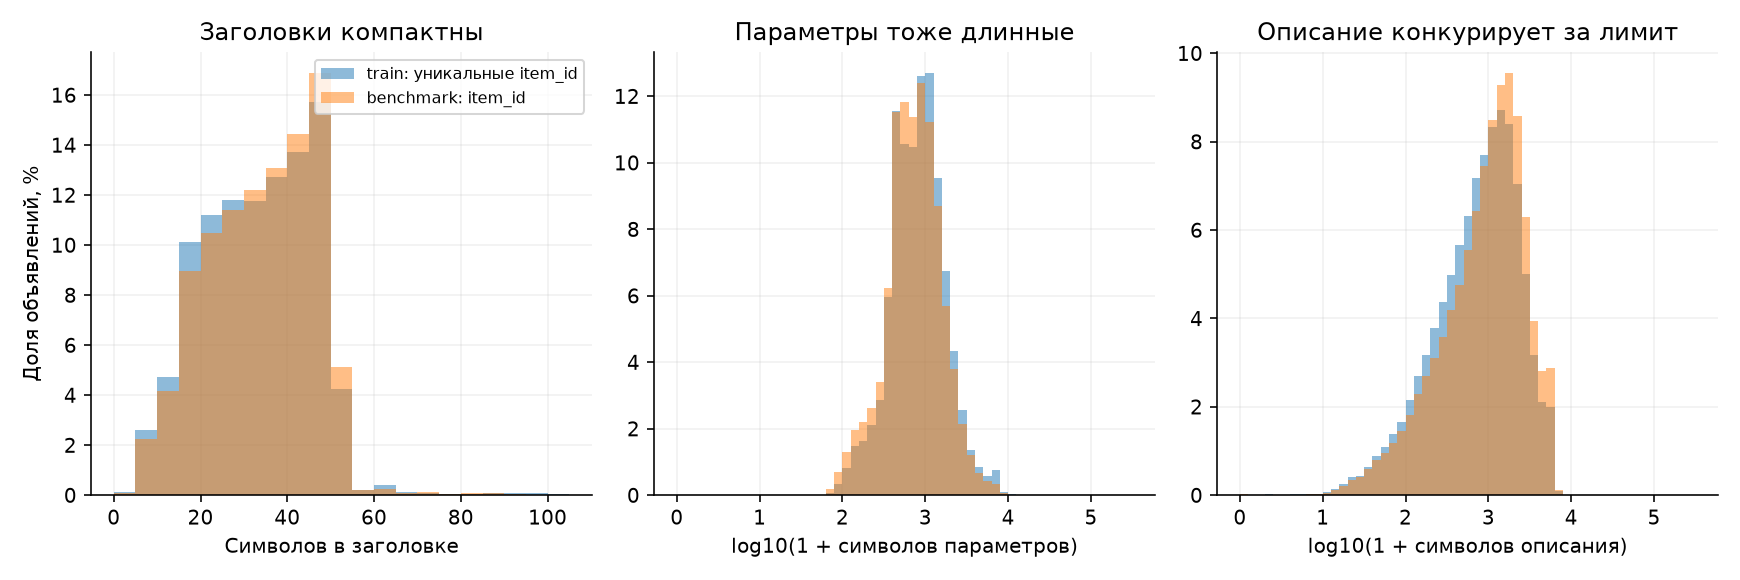

In [12]:
report.section("8. Длинные описания и повторяющееся содержание")
_output_start = len(report.body)
length_rows, duplicate_rows = [], []
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
for name, frame in item_frames.items():
    lengths = frame.select(
        [pl.col(c).fill_null("").str.len_chars().alias(c) for c in TEXT]
    )
    for column in TEXT:
        length_rows.append(quantiles(lengths, column, name))
    for ax, column, bins in [
        (axes[0], "item_title_raw", np.linspace(0, 105, 22)),
        (axes[1], "item_infm_params_text", np.linspace(0, 5.5, 56)),
        (axes[2], "item_description_raw", np.linspace(0, 5.5, 56)),
    ]:
        values = lengths[column].to_numpy()
        if column != "item_title_raw":
            values = np.log10(1 + values)
        ax.hist(
            values,
            bins=bins,
            weights=np.ones(len(values)) * 100 / len(values),
            alpha=0.5,
            label=name,
        )
    duplicate_rows.append(
        {
            "dataset": name,
            "repeated_titles_extra_ids": frame.height
            - frame.select(normalize("item_title_raw")).n_unique(),
            "repeated_full_text_extra_ids": frame.height
            - frame.select([normalize(c) for c in TEXT]).n_unique(),
            "description_over_2000_chars": lengths.filter(
                pl.col("item_description_raw") > 2000
            ).height,
            "description_with_html_tag": frame.filter(
                pl.col("item_description_raw").fill_null("").str.contains(r"<[^>]+>")
            ).height,
        }
    )
axes[0].set(
    xlabel="Символов в заголовке",
    ylabel="Доля объявлений, %",
    title="Заголовки компактны",
)
axes[1].set(xlabel="log10(1 + символов параметров)", title="Параметры тоже длинные")
axes[2].set(
    xlabel="log10(1 + символов описания)", title="Описание конкурирует за лимит"
)
axes[0].legend(fontsize=8)
report.figure(
    "text_lengths",
    figure,
    "Считаются Unicode-символы, не токены E5. Null считается длиной 0. Точную долю усечения на 512 токенах нужно измерить выбранным токенизатором при реализации dense-поиска.",
)
report.table("item_text_lengths", pl.DataFrame(length_rows))
report.table("text_duplicates", pl.DataFrame(duplicate_rows))
text_train = train_items.select([normalize(c) for c in TEXT]).unique()
new_items = items.join(train_items.select("item_id"), on="item_id", how="anti")
new_text_seen = (
    new_items.select([normalize(c) for c in TEXT])
    .join(text_train, on=TEXT, how="semi")
    .height
)
metrics["new_item_ids_with_seen_full_text"] = new_text_seen
report.paragraph(
    f"Среди {fmt(new_items.height)} новых item_id benchmark у {fmt(new_text_seen)} ({percent(new_text_seen, new_items.height)}) совпадает весь нормализованный текст: заголовок + параметры + описание. Нормализация только регистра, ё/е и пробелов; совпадение текста не учитывает город и не доказывает тождество услуги. Дубли нельзя безусловно удалить: каждый ID может быть правильным ответом."
)
report.paragraph(
    "Параметры benchmark достигают 19 068 символов; медиана 738. Простое помещение всех параметров перед описанием может полностью вытеснить описание из 512 токенов. При подготовке dense проверить отдельные бюджеты для параметров и описания, сохранив заголовок. Для BM25 сравнить повышенный вес заголовка. Нельзя утверждать, что 2 000 символов равны 512 токенам. Похожие объявления с разными ID объясняют часть возможных промахов по поведенческой метрике."
)
report.table(
    "item_categories",
    pl.concat([distribution(f, "item_category_id", n) for n, f in item_frames.items()]),
    limit=20,
)
report.table(
    "item_microcategories",
    pl.concat(
        [
            distribution(f, "item_microcat_id", n).head(15)
            for n, f in item_frames.items()
        ]
    ),
    limit=30,
)

display(HTML("".join(report.body[_output_start:])))

**Вывод.** Тексты объявлений длинные: медиана описания 1 054 символа, у 46 344 объявлений benchmark (24%) — больше 2 000; параметры в медиане 738 символов, максимум 19 068. Dense-энкодер читает только 512 токенов, поэтому документ собирается как заголовок → параметры → описание, а длину параметров придётся ограничить, чтобы они не вытеснили описание.

Заголовки часто одинаковые: 71 193 объявления benchmark повторяют чужой заголовок, так что по одному заголовку исполнителей не различить. Полных дублей текста почти нет (15). Категория у 99% корпуса одна — 114, различение идёт через микрокатегорию и текст.

## 9. Насколько хватает буквальных совпадений

field,sample_size,zero_overlap_pct,all_query_tokens_pct,mean_coverage
title_coverage,20 000,28.38,36.54,0.53
title_params_coverage,20 000,16.19,48.18,0.66
full_text_coverage,20 000,7.08,67.56,0.82

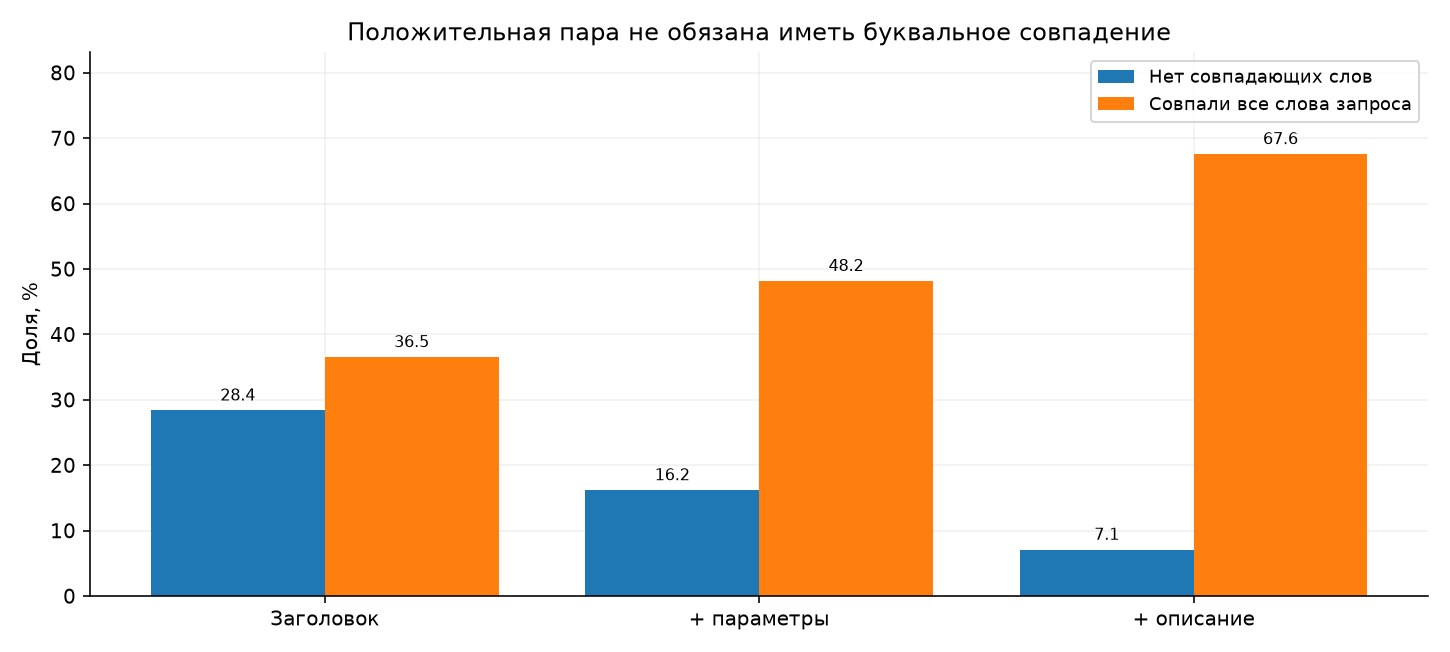

In [13]:
report.section("9. Насколько хватает буквальных совпадений")
_output_start = len(report.body)
sample = pairs.sample(n=min(20_000, pairs.height), seed=SEED, shuffle=True)
token_pattern = re.compile(r"[^\W_]+", flags=re.UNICODE)


def tokens(text: str | None) -> set[str]:
    return set(token_pattern.findall((text or "").lower().replace("ё", "е")))


lexical_rows = []
for row in sample.select(
    QUERY + ["item_id", *TEXT, "item_location_id", "item_category_id"]
).iter_rows(named=True):
    query_tokens = tokens(row["search_query"])
    if not query_tokens:
        continue
    title_tokens = tokens(row["item_title_raw"])
    params_tokens = tokens(row["item_infm_params_text"])
    all_tokens = title_tokens | params_tokens | tokens(row["item_description_raw"])
    lexical_rows.append(
        {
            "item_id": row["item_id"],
            **{c: row[c] for c in QUERY},
            "title_coverage": len(query_tokens & title_tokens) / len(query_tokens),
            "title_params_coverage": len(query_tokens & (title_tokens | params_tokens))
            / len(query_tokens),
            "full_text_coverage": len(query_tokens & all_tokens) / len(query_tokens),
        }
    )
lexical = pl.DataFrame(lexical_rows)
coverage_fields = ["title_coverage", "title_params_coverage", "full_text_coverage"]
lexical_summary = pl.DataFrame(
    [
        {
            "field": c,
            "sample_size": lexical.height,
            "zero_overlap_pct": 100 * lexical.select((pl.col(c) == 0).mean()).item(),
            "all_query_tokens_pct": 100
            * lexical.select((pl.col(c) == 1).mean()).item(),
            "mean_coverage": lexical[c].mean(),
        }
        for c in coverage_fields
    ]
)
report.table("lexical_coverage", lexical_summary)
metrics["lexical_coverage"] = lexical_summary.to_dicts()
bar_compare(
    report,
    "lexical_coverage",
    ["Заголовок", "+ параметры", "+ описание"],
    {
        "Нет совпадающих слов": lexical_summary["zero_overlap_pct"].to_list(),
        "Совпали все слова запроса": lexical_summary["all_query_tokens_pct"].to_list(),
    },
    "Положительная пара не обязана иметь буквальное совпадение",
    "Случайная выборка 20 000 уникальных пар, seed=42. Слова — Unicode-буквы/цифры; нижний регистр, ё/е, без морфологии и удаления стоп-слов. Это не качество BM25.",
)
report.paragraph(
    "Нулевое пересечение слов может объясняться словоформами, синонимами, опечаткой, неполным объявлением или шумом поведения. Оно не доказывает необходимость конкретной нейросети. Проверяем морфологию и семантический канал независимыми абляциями. Совпадение всех слов тоже не доказывает правильную услугу."
)

display(HTML("".join(report.body[_output_start:])))

**Вывод.** Совпадения слов полезны, но их не хватает. На 20 000 случайных пар:

- все слова запроса есть в заголовке выбранного объявления только в 36,5% случаев, ни одного общего слова — в 28,4%;
- по полному тексту (заголовок + параметры + описание) все слова находятся в 67,6%, ни одного — в 7,1%.

Значит, индексировать нужно весь текст, а не заголовок. Оставшиеся расхождения — словоформы, синонимы, опечатки, транслит. Их закрывают морфология в BM25 и семантический dense-поиск.

## 10. Примеры для самостоятельного просмотра

In [14]:
report.section("10. Примеры для самостоятельного просмотра")
_output_start = len(report.body)


def short(text, length=180):
    # Limit public excerpts and suppress obvious phone/e-mail strings.
    value = re.sub(r"\s+", " ", str(text or ""))
    value = re.sub(r"\b[^\s@]+@[^\s@]+\.[^\s@]+\b", "[email]", value)
    value = re.sub(r"(?<!\w)\+?\d[\d ()-]{8,}\d(?!\w)", "[телефон/число]", value)
    return value[:length] + ("…" if len(value) > length else "")


zero_overlap = lexical.filter(pl.col("full_text_coverage") == 0).select(pair_columns)
examples = []
cases = [
    (
        "Разные location_id",
        pairs.filter(pl.col("search_location_id") != pl.col("item_location_id")),
    ),
    (
        "Разная категория",
        pairs.filter(pl.col("search_category") != pl.col("item_category_id")),
    ),
    (
        "Нет общих слов",
        pairs.join(zero_overlap, on=pair_columns, how="semi", nulls_equal=True),
    ),
    (
        "Описание >5 000 символов",
        pairs.filter(pl.col("item_description_raw").str.len_chars() > 5_000),
    ),
    ("Цена 0 или 1", pairs.filter(pl.col("item_price").is_in([0, 1]))),
]
for reason, frame in cases:
    for row in (
        frame.unique(pair_columns, maintain_order=True)
        .sort(pair_columns)
        .head(5)
        .iter_rows(named=True)
    ):
        examples.append(
            {
                "Особенность": reason,
                "Запрос": short(row["search_query"]),
                "Фильтры": short(row["search_infm_params_text"], 100),
                "Заголовок": short(row["item_title_raw"]),
                "Город запроса/объявления": f"{row['search_location_id']}/{row['item_location_id']}",
                "Категория запроса/объявления": f"{row['search_category']}/{row['item_category_id']}",
                "Цена": float(row["item_price"])
                if row["item_price"] is not None
                else None,
                "item_id": row["item_id"],
            }
        )
report.table("examples", pl.DataFrame(examples), limit=30)
report.paragraph(
    "Это до 25 намеренно выбранных иллюстраций, а не случайная выборка и не ошибки ещё не обученной модели. Внутри каждой группы берутся первые пять уникальных пар в лексикографическом порядке полного запроса и item_id. Один пример может попадать в несколько групп. Все пары отмечены положительными в train; ID позволяет найти полное описание локально. Не исправляем метки вручную на основании этих примеров."
)

display(HTML("".join(report.body[_output_start:])))

Особенность,Запрос,Фильтры,Заголовок,Город запроса/объявления,Категория запроса/объявления,Цена,item_id
Разные location_id,"""установка рулевой колонки на лодку пвх""",,Тюнинг лодок пвх,107620/637640,114/114,800.00,9d22e6e798d0ef38
Разные location_id,1 с,,Программист 1С. Настройка. Обновление,621540/637640,114/114,1 000.00,82f6a3e13d98fcda
Разные location_id,115 фз,Вид услуги Деловые услуги,Разблокировка счета и карты 161-фз / 115-фз,107620/637640,114/114,4 500.00,71739f5694279a3c
Разные location_id,115 фз,Вид услуги Деловые услуги,Снятие ограничений Банка по 115-фз,621540/640160,114/114,5 000.00,10d398e311f7d2e8
Разные location_id,115 фз,Вид услуги Деловые услуги Тип услуги Юридические услуги,Разблокировка счета по 115 и 161 фз,621550/621565,114/114,1 000.00,e68defda431f9556
Разная категория,[телефон/число],,Автосервис ваз,621540/625810,10/114,300.00,cc23e5127ffdc010
Разная категория,tokio inkarami,,Парикмахер стилист,637640/637640,0/114,5 200.00,daf922e0c60e9240
Разная категория,автозаправка кондиционеров,,"Промывка, ремонт и заправка кондиционеров",633655/633540,0/114,500.00,2d01c2e1761bd43c
Разная категория,аренда кабинета педикюра,"Вид услуги Красота, здоровье",Оборудование для лазерной эпиляции,649870/649870,114/40,1 000.00,3b0a132d82300479
Разная категория,аренда с выкупом,,Аренда автомобиля,656350/656350,0/114,7 500.00,ede49f8b9b3f6e92


**Вывод.** Примеры показывают, как выглядят трудные случаи: выбранное объявление из другого `location_id` (юридические услуги по 115-ФЗ, программист 1С — работают удалённо), запрос из номера телефона или числа, транслит и опечатка (`goofish` → «gofish»), условная цена 0 или 1. Это намеренно отобранные иллюстрации, а не оценка частоты таких ошибок.

## 11. Что меняем в поиске на основании данных

In [15]:
report.section("11. Что меняем в поиске на основании данных")
_output_start = len(report.body)
report.table(
    "decisions",
    pl.DataFrame(
        [
            {
                "Наблюдение": "Много новых текстов и item_id",
                "Действие": "Split по нормализованным текстам; поиск по содержанию; отдельный срез новых объявлений",
                "Как проверить": "Recall@50 на dev и cold-item срезе",
            },
            {
                "Наблюдение": "Позитивы с другим location_id; геоиерархия неизвестна",
                "Действие": "Глобальный поиск + дополнительные локальные кандидаты; мягкая география",
                "Как проверить": "Полнота пула и Recall@50 с локальным каналом и без него",
            },
            {
                "Наблюдение": "Категория 0 и пустые фильтры чаще в benchmark",
                "Действие": "Без жёсткого фильтра по категории; признаки отсутствия",
                "Как проверить": "Отдельные срезы категории 0 и пустых фильтров",
            },
            {
                "Наблюдение": "Короткие запросы и несовпадающие словоформы",
                "Действие": "BM25 с морфологией + dense; фильтры включить в представление запроса",
                "Как проверить": "BM25 / dense / hybrid на одном dev",
            },
            {
                "Наблюдение": "Длинные описания и параметры",
                "Действие": "Защитить заголовок; проверить бюджеты параметров и описания",
                "Как проверить": "Доля усечённых текстов и Recall по длине",
            },
            {
                "Наблюдение": "Повторы пар и много позитивов у части контекстов",
                "Действие": "Множества позитивов по полному запросу, macro Recall; исключать известные позитивы из негативов",
                "Как проверить": "Тест метрики на нескольких позитивах и дублях",
            },
            {
                "Наблюдение": "Пропуски рейтинга, цена −1, условные цены, длинные хвосты",
                "Действие": "Индикаторы пропуска/отрицательной цены; не брать log1p от −1",
                "Как проверить": "Конечность числовых признаков; прирост CatBoost на том же пуле",
            },
        ]
    ),
)
report.paragraph(
    "Приоритет: сначала split и корректная метрика, затем BM25 baseline, dense, гибрид и CatBoost. Разделять полноту пула и Recall@50 после отбора. EDA не доказывает прирост ни одного компонента; финальный выбор только по dev, test — один раз после выбора. Осмотр train для EDA допустим, но это не полностью слепое исследование будущего локального test; не превращать просмотренные примеры в ручные правила."
)

display(HTML("".join(report.body[_output_start:])))

Наблюдение,Действие,Как проверить
Много новых текстов и item_id,Split по нормализованным текстам; поиск по содержанию; отдельный срез новых объявлений,Recall@50 на dev и cold-item срезе
Позитивы с другим location_id; геоиерархия неизвестна,Глобальный поиск + дополнительные локальные кандидаты; мягкая география,Полнота пула и Recall@50 с локальным каналом и без него
Категория 0 и пустые фильтры чаще в benchmark,Без жёсткого фильтра по категории; признаки отсутствия,Отдельные срезы категории 0 и пустых фильтров
Короткие запросы и несовпадающие словоформы,BM25 с морфологией + dense; фильтры включить в представление запроса,BM25 / dense / hybrid на одном dev
Длинные описания и параметры,Защитить заголовок; проверить бюджеты параметров и описания,Доля усечённых текстов и Recall по длине
Повторы пар и много позитивов у части контекстов,"Множества позитивов по полному запросу, macro Recall; исключать известные позитивы из негативов",Тест метрики на нескольких позитивах и дублях
"Пропуски рейтинга, цена −1, условные цены, длинные хвосты",Индикаторы пропуска/отрицательной цены; не брать log1p от −1,Конечность числовых признаков; прирост CatBoost на том же пуле


## 12. Ограничения и воспроизводимость

In [16]:
report.section("12. Ограничения и воспроизводимость")
_output_start = len(report.body)
report.paragraph(
    "Неизвестны временной порядок, показы, user_id, причины выбора, смысл кодов городов/категории 0 и отрицательные метки. Нельзя оценить конверсию, причинные эффекты рейтинга, временной дрейф или истинную долю нерелевантных объявлений. Сравниваются распределения предоставленных файлов, а не генеральная совокупность Авито. Анализ benchmark использует только доступные признаки; скрытых ответов нет."
)
report.paragraph(
    "Схема исходных Decimal сохранена. Float64 используется только для графиков и квантилей; ID всегда остаются строками. Все статистики полные, кроме лексической выборки. SHA-256 входов и версии окружения находятся в переменной summary и таблицах ниже. При одинаковом окружении и файлах повторный запуск должен давать те же таблицы и графики."
)
fingerprints = {
    key: {"file": path.name, "bytes": path.stat().st_size, "sha256": sha256(path)}
    for key, path in paths.items()
}
metrics.update(
    {
        "inputs": fingerprints,
        "seed": SEED,
        "lexical_sample_size": sample.height,
        "versions": {
            "python": platform.python_version(),
            "polars": pl.__version__,
            "numpy": np.__version__,
            "matplotlib": matplotlib.__version__,
        },
        "item_attribute_conflicts": variation_counts,
        "integrity": integrity,
    }
)
summary = metrics
report.table(
    "input_fingerprints",
    pl.DataFrame([{"dataset": key, **value} for key, value in fingerprints.items()]),
)
report.table(
    "environment",
    pl.DataFrame(
        [
            {"package": key, "version": value}
            for key, value in summary["versions"].items()
        ]
    ),
)
display(HTML("".join(report.body[_output_start:])))

## Самостоятельное исследование

Все данные остаются доступны в памяти: `train`, `queries`, `items`, `pairs`, `train_items` и `contexts`. Список готовых таблиц: `sorted(report.tables)`. Например, `report.tables["locations_without_items"]` покажет все коды локаций без кандидатов, а `report.tables["numeric_anomalies"]` — числовые проверки без ограничения числа строк.

Чтобы посмотреть объявление из примеров, скопируйте его `item_id` в ячейку ниже. Это чтение train, а не ручная корректировка разметки. После знакомства с данными следующий шаг — зафиксировать split и метрику Recall@50.

In [17]:
# Замените ID на интересующий из таблицы примеров.
example_item_id = report.tables["examples"]["item_id"][0]
example = train_items.filter(pl.col("item_id") == example_item_id)
with pl.Config(tbl_cols=14, fmt_str_lengths=160):
    display(
        example.select(
            "item_id",
            "item_title_raw",
            "item_price",
            "item_location_id",
            "item_infm_params_text",
            "item_description_raw",
        )
    )

item_id,item_title_raw,item_price,item_location_id,item_infm_params_text,item_description_raw
str,str,"decimal[27,15]",i64,str,str
"""9d22e6e798d0ef38""","""Тюнинг лодок пвх""",800.000000000000000,637640,"""Вид услуги Автосервис, аренда Тип услуги Место оказания услуг Москва, Абрамцевская улица, вл30 Гарантия Опыт работы 8 Начальная цена Время для связи от 32400 Вр…","""✅ Тюнинг и ремонт лодок ПВХ 📲 ЗВОНИТЕ И ЗАПИСЫВАЙТЕСЬ! МЕСТА ЕСТЬ! НАШЕ ПРЕИМУЩЕСТВО - КАЧЕСТВО И В СРОК!!! Вам не придется бегать за нами, дозваниваться, пе…"
